In [51]:
import pandas as pd
import plotly.express as px
from google.colab import files
##uploaded = files.upload()
file_path = 'sample_data/sales_data.csv'
df = pd.read_csv(file_path)
print(df.isna().sum())
sales_median = df['sales'].median()
region_mode = df['region'].mode()[0]
df['sales'] = df['sales'].fillna(sales_median)
df['region'] = df['region'].fillna(region_mode)
print(df.isna().sum())
df['month'] = pd.to_datetime(df['month'])
df = df.sort_values('month')
region_choice = 'North'
north_data = df[df['region'] == region_choice].copy()
north_data['rolling_avg'] = (north_data['sales'].rolling(window=3).mean())
fig = px.line(df,
              x='month', y='sales', color="region",
              markers=True, title='Monthly sales trend by region')
fig.add_scatter(x=north_data['month'],y=north_data['rolling_avg'],mode='lines',line=dict(dash='dash',color='black'),name="North: 3 month rolling avg")
fig.show()

month     0
region    2
sales     5
dtype: int64
month     0
region    0
sales     0
dtype: int64


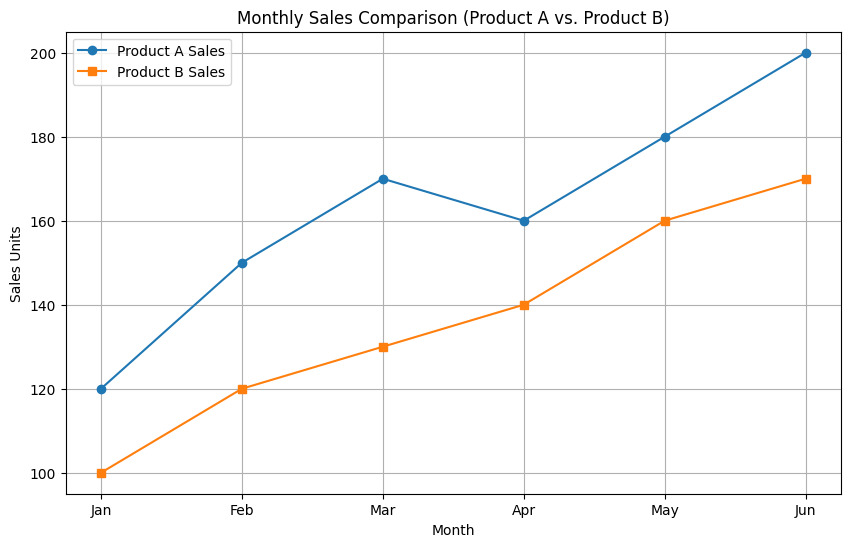

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Month": ["Jan", "Feb", "Mar", "Apr", "May", "Jun"],
    "Product_A_Sales": [120, 150, 170, 160, 180, 200],
    "Product_B_Sales": [100, 120, 130, 140, 160, 170]
}
df = pd.DataFrame(data)

plt.figure(figsize=(10, 6))
plt.plot(df["Month"], df["Product_A_Sales"], label="Product A Sales", marker='o')
plt.plot(df["Month"], df["Product_B_Sales"], label="Product B Sales", marker='s')

plt.title("Monthly Sales Comparison (Product A vs. Product B)")
plt.xlabel("Month")
plt.ylabel("Sales Units")
plt.legend(loc="upper left")
plt.grid(True)
plt.show()


In [89]:
import pandas as pd
url = 'https://raw.githubusercontent.com/plotly/datasets/master/2011_us_ag_exports.csv'
df = pd.read_csv(url)
df.head()



,code,state,category,total exports,beef,pork,poultry,dairy,fruits fresh,fruits proc,total fruits,veggies fresh,veggies proc,total veggies,corn,wheat,cotton
0,AL,Alabama,state,1390.63,34.4,10.6,481.0,4.06,8.0,17.1,25.11,5.5,8.9,14.33,34.9,70.0,317.61
1,AK,Alaska,state,13.31,0.2,0.1,0.0,0.19,0.0,0.0,0.00,0.6,1.0,1.56,0.0,0.0,0.00
2,AZ,Arizona,state,1463.17,71.3,17.9,0.0,105.48,19.3,41.0,60.27,147.5,239.4,386.91,7.3,48.7,423.95
3,AR,Arkansas,state,3586.02,53.2,29.4,562.9,3.53,2.2,4.7,6.88,4.4,7.1,11.45,69.5,114.5,665.44
4,CA,California,state,16472.88,228.7,11.1,225.4,929.95,2791.8,5944.6,8736.40,803.2,1303.5,2106.79,34.6,249.3,1064.95


In [77]:
df['total_meat_exports'] = df['beef'] + df['pork'] + df['poultry']
dftop12 = df.sort_values('total_meat_exports', ascending = False).head(12)
plot_df = dftop12.melt(id_vars=["state"], value_vars=["beef", "pork", "poultry"], var_name="meat_type", value_name="export_value")
fig = px.line(
    plot_df,
    x="state",
    y="export_value",
    color="meat_type",
    markers=True,
    title="Top 12 States by Beef, Pork & Poultry Exports (2011)",
    labels={
        "state": "State",
        "export_value": "Export Value (Millions USD)",
        "meat_type": "Meat Category"
    }
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [70]:
df_beeftop5 = df.sort_values('beef', ascending=False).head(5)
fig = px.pie(df_beeftop5,
       names="state", values="beef",
       title="Top 5 States by Beef Exports (2011)", hole=0)
fig.update_traces(textposition="inside", textinfo="percent+label")
fig.show()

In [75]:
df_pork_sorted = df.sort_values('pork', ascending=False)
df_pork_sorted.head()
fig = px.bar(
    df_pork_sorted,
    x="state",
    y="pork",
    title="Pork Exports by State (2011)",
    labels={"pork": "Pork Export Value", "state": "State"},
)
# 4. Force y-axis to start at 0
fig.update_yaxes(range=[0, df_pork_sorted["pork"].max() * 1.1])
# ^ gives a bit of headroom above the tallest bar
fig.show()

In [87]:
fig = px.scatter(
    df,
    x="corn",
    y="wheat",
    color="state",
    title="Scatter Plot: Corn vs Wheat Exports (2011)",
    hover_name="state",
    labels={"corn":"Corn Export Value", "wheat":"Wheat Export Value"},
    trendline="ols",  # Adds a linear trendline to observe correlation
    trendline_scope="overall"
)

fig.show()

In [8]:
import pandas as pd
url = 'https://raw.githubusercontent.com/plotly/datasets/master/2011_us_ag_exports.csv'
df = pd.read_csv(url)
df.head()

plot_df = df.melt(
    id_vars="state",
    value_vars=["dairy", "total fruits"],
    var_name="export_type",
    value_name="export_value"
)

fig = px.line(
    plot_df,
    #df,
    x="state",
    y="export_value",
    #y=["dairy", "total fruits"],
    color="export_type",
    markers=True,
    title="Dairy vs Fruits Exports Across States (2011)",
    labels={
        "state": "State",
        "export_value": "Export Value",
        "export_type": "Export Type"
    }
)
# Rotate x-axis labels
fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [6]:
import pandas as pd
import plotly.express as px
url = 'https://raw.githubusercontent.com/plotly/datasets/master/2011_us_ag_exports.csv'
df = pd.read_csv(url)
df.head()
fig = px.bar(
    df,
    x="state",
    y=["total veggies", "total fruits"],   # Multiple columns
    title="Vegetables vs Fruits Exports by State (2011)",
    labels={
        "value": "Export Value",
        "variable": "Category",
        "state": "State"
    },
    barmode="group"
)
# plot_df = df.melt(
#     id_vars="state",
#     value_vars=["total veggies", "total fruits"],
#     var_name="export_type",
#     value_name="export_value"
# )

# fig = px.bar(
#     plot_df,
#     x="state",
#     y="export_value",
#     color="export_type",
#     barmode="group",   # <-- Grouped bars
#     title="Vegetables vs Fruits Exports by State (2011)",
#     labels={
#         "state": "State",
#         "export_value": "Export Value",
#         "export_type": "Category"
#     }
# )

# Rotate labels for readability
fig.update_layout(xaxis_tickangle=-90)

fig.show()

In [9]:
import pandas as pd
import plotly.express as px

# 1. Load dataset
url = "https://raw.githubusercontent.com/plotly/datasets/master/2011_us_ag_exports.csv"
df = pd.read_csv(url)

# 2. Clean column names
df.columns = df.columns.str.lower().str.strip()

# 3. Create an outlier flag column
df["outlier"] = df["corn"] > 200

# 4. Create scatter plot
fig = px.scatter(
    df,
    x="state",
    y="corn",
    color="outlier",   # Colors based on outlier status
    color_discrete_map={
        True: "red",     # Outliers
        False: "blue"    # Normal points
    },
    title="Corn Exports by State (Outliers Highlighted)",
    labels={
        "corn": "Corn Export Value",
        "state": "State",
        "outlier": "Outlier (>200)"
    },
    hover_name="state"
)

# Rotate x-axis labels
fig.update_layout(xaxis_tickangle=-45)

fig.show()

In [12]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Load dataset
url = "https://raw.githubusercontent.com/plotly/datasets/master/2011_us_ag_exports.csv"
df = pd.read_csv(url)

# 2. Clean column names
df.columns = df.columns.str.lower().str.strip()

# 3. Create 2x2 subplots
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[
        "Corn Exports",
        "Wheat Exports",
        "Cotton Exports",
        "Vegetables Exports"
    ]
)

# 4. Add Corn
fig.add_trace(
    go.Bar(x=df["state"], y=df["corn"], name="Corn"),
    row=1, col=1
)

# 5. Add Wheat
fig.add_trace(
    go.Bar(x=df["state"], y=df["wheat"], name="Wheat"),
    row=1, col=2
)

# 6. Add Cotton
fig.add_trace(
    go.Bar(x=df["state"], y=df["cotton"], name="Cotton"),
    row=2, col=1
)

# 7. Add Veggies
fig.add_trace(
    go.Bar(x=df["state"], y=df["total veggies"], name="Veggies"),
    row=2, col=2
)

# 8. Update layout
fig.update_layout(
    title="2×2 Comparison of Agricultural Exports (2011)",
    height=800,
    showlegend=False
)

# Rotate x-axis labels for readability
fig.update_xaxes(tickangle=-90)

fig.show()

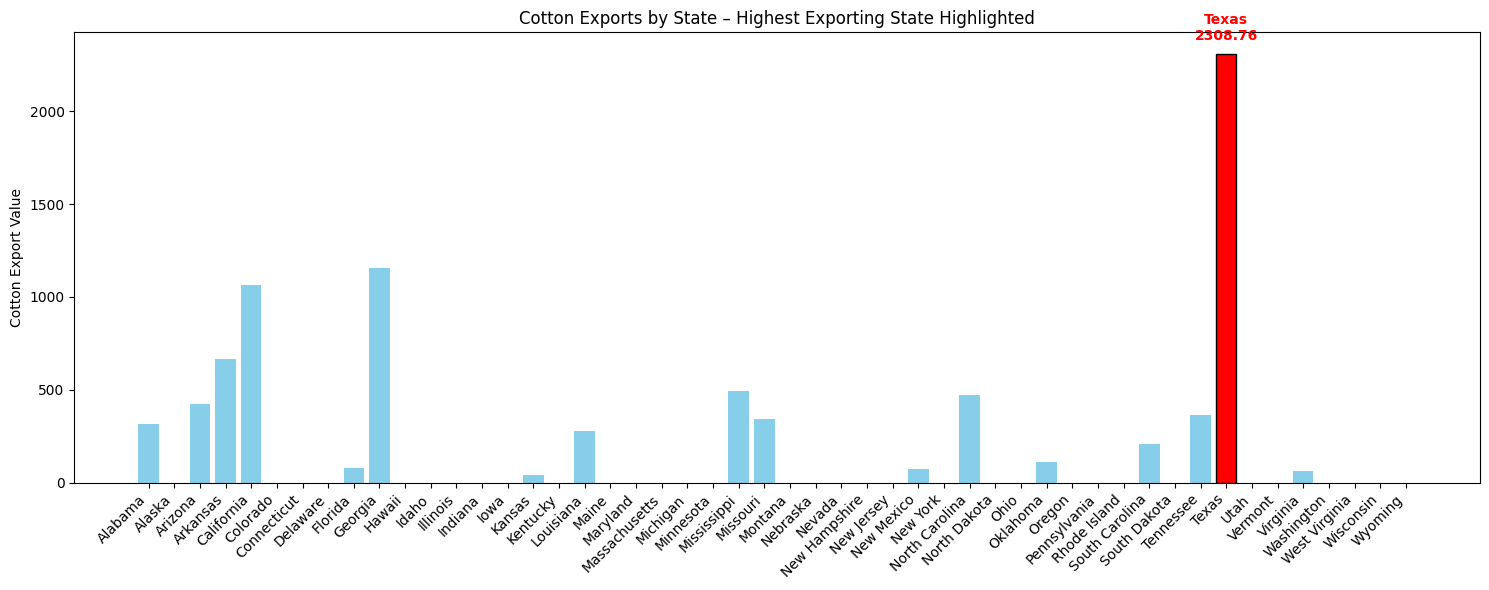

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset
url = "https://raw.githubusercontent.com/plotly/datasets/master/2011_us_ag_exports.csv"
df = pd.read_csv(url)

# 2. Clean up column names
df.columns = df.columns.str.lower().str.strip()

# 3. Find the highest state for cotton
max_cotton_value = df["cotton"].max()
max_cotton_state = df[df["cotton"] == max_cotton_value]["state"].values[0]

# 4. Create the bar chart
plt.figure(figsize=(15, 6))
bars = plt.bar(df["state"], df["cotton"], color="skyblue")

# 5. Highlight the highest exporting state
for bar in bars:
    if bar.get_height() == max_cotton_value:
        bar.set_color("red")
        bar.set_edgecolor("black")
        highest_bar = bar

# 6. Annotate the bar
plt.annotate(
    f"{max_cotton_state}\n{max_cotton_value}",
    xy=(highest_bar.get_x() + highest_bar.get_width() / 2, highest_bar.get_height()),
    xytext=(0, 10),
    textcoords="offset points",
    ha="center",
    fontsize=10,
    fontweight="bold",
    color="red"
)

# 7. Labels and title
plt.xticks(rotation=45, ha="right")
plt.ylabel("Cotton Export Value")
plt.title("Cotton Exports by State – Highest Exporting State Highlighted")

plt.tight_layout()
plt.show()


In [15]:
import pandas as pd
import plotly.express as px

# 1. Load dataset
url = "https://raw.githubusercontent.com/plotly/datasets/master/2011_us_ag_exports.csv"
df = pd.read_csv(url)

# 2. Clean column names
df.columns = df.columns.str.lower().str.strip()

# 3. Find highest cotton export
max_row = df.loc[df["cotton"].idxmax()]

max_state = max_row["state"]
max_value = max_row["cotton"]

# 4. Create bar chart
fig = px.bar(
    df,
    x="state",
    y="cotton",
    title="Cotton Exports by State (Highest Highlighted)",
    labels={
        "state": "State",
        "cotton": "Cotton Export Value"
    }
)

# 5. Add annotation for highest value
fig.add_annotation(
    x=max_state,
    y=max_value,
    text=f"Highest: {max_state}<br>{max_value}",
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowcolor="red",
    font=dict(color="red", size=12),
    yshift=15
)

# 6. Rotate x-axis labels
fig.update_layout(xaxis_tickangle=-45)

fig.show()


In [21]:
import pandas as pd
import plotly.express as px

# 1. Load dataset
url = "https://raw.githubusercontent.com/plotly/datasets/master/2011_us_ag_exports.csv"
df = pd.read_csv(url)

# 2. Clean column names
df.columns = df.columns.str.lower().str.strip()

# 3. Create scatter plot (colored by region)
fig = px.scatter(
    df,
    x="corn",
    y="wheat",
    color="state",
    hover_name="state",
    title="Corn vs Wheat Exports (High Export Regions Annotated)",
    labels={
        "corn": "Corn Export Value",
        "wheat": "Wheat Export Value",
        "state": "Region"
    }
)

# 4. Filter points where both corn and wheat > 500
high_export = df[(df["corn"] > 500) & (df["wheat"] > 500)]

# 5. Add annotations for these points
for _, row in high_export.iterrows():
    fig.add_annotation(
        x=row["corn"],
        y=row["wheat"],
        text=row["state"],
        showarrow=True,
        arrowhead=2,
        arrowsize=1,
        arrowcolor="red",
        font=dict(color="red", size=11),
        yshift=12
    )

# 6. Show plot
fig.show()


In [23]:
import pandas as pd
import plotly.express as px

# 1. Load dataset
url = "https://raw.githubusercontent.com/plotly/datasets/master/2014_usa_states.csv"
df = pd.read_csv(url)

# 2. Sort by population and select top 10 states
top10 = df.sort_values(by="Population", ascending=False).head(10)

# 3. Create donut chart with color-blind friendly palette
fig = px.pie(
    top10,
    names="State",
    values="Population",
    title="Top 10 US States by Population (2014)",
    hole=0.2,   # Makes it a donut chart
    color_discrete_sequence=px.colors.qualitative.Safe  # Color-blind safe palette
)

# 4. Show percentage + label
fig.update_traces(
    textinfo="percent+label",
    textposition="inside"
)

# 5. Improve layout
fig.update_layout(
    showlegend=True,
    uniformtext_minsize=10,
    uniformtext_mode="hide"
)

fig.show()


In [26]:
import pandas as pd
import plotly.express as px

# 1. Load dataset
url = "https://raw.githubusercontent.com/plotly/datasets/master/2014_usa_states.csv"
df = pd.read_csv(url)
df.head()
# 2. Calculate percentiles for Population
p25 = df["Population"].quantile(0.25)
p75 = df["Population"].quantile(0.75)

# 3. Create percentile-based category
def classify(pop):
    if pop > p75:
        return "Above 75th Percentile"
    elif pop < p25:
        return "Below 25th Percentile"
    else:
        return "25–75th Percentile"

df["population_group"] = df["Population"].apply(classify)

# 4. Create decluttered scatter plot
fig = px.scatter(
    df,
    x="State",
    y="Population",
    color="population_group",
    hover_name="State",
    title="US States: Population vs Area (Percentile Grouped)",
    labels={
        "State": "Area (sq miles)",
        "Population": "Population",
        "population_group": "Population Category"
    },
    color_discrete_map={
        "Above 75th Percentile": "red",
        "25–75th Percentile": "blue",
        "Below 25th Percentile": "green"
    }
)

# 5. Improve readability
fig.update_layout(
    template="plotly_white",
    legend_title="Groups"
)

fig.show()

In [27]:
import pandas as pd
import plotly.express as px

# 1. Load dataset
url = "https://raw.githubusercontent.com/plotly/datasets/master/2014_usa_states.csv"
df = pd.read_csv(url)

# --------------------------------------------------
# Task 1: Define a Custom Color-Blind Safe Palette
# --------------------------------------------------

# Custom accessible palette (high contrast, safe colors)
CB_PALETTE = [
    "#0072B2",  # Blue
    "#E69F00",  # Orange
    "#009E73",  # Green
    "#D55E00",  # Red-orange
    "#CC79A7",  # Pink
    "#56B4E9",  # Light Blue
    "#F0E442"   # Yellow
]

# --------------------------------------------------
# Task 2A: Histogram (Population Distribution)
# --------------------------------------------------

fig_hist = px.histogram(
    df,
    x="Population",
    nbins=15,
    title="Population Distribution of US States (2014)",
    color_discrete_sequence=CB_PALETTE
)

fig_hist.update_layout(
    template="plotly_white",
    xaxis_title="Population",
    yaxis_title="Count"
)

fig_hist.show()

# --------------------------------------------------
# Task 2B: Bar Chart (Top 10 States by Population)
# --------------------------------------------------

# Select top 10 states
top10 = df.sort_values("Population", ascending=False).head(10)

fig_bar = px.bar(
    top10,
    x="State",
    y="Population",
    title="Top 10 States by Population (2014)",
    color="State",   # Forces multiple colors
    color_discrete_sequence=CB_PALETTE
)

fig_bar.update_layout(
    template="plotly_white",
    xaxis_tickangle=-45,
    showlegend=False,
    xaxis_title="State",
    yaxis_title="Population"
)

fig_bar.show()
